# Day 08. Exercise 01
# Binary classifier. SVM. Decision tree

## 0. Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC
import numpy as np

## 1. Preprocessing and logreg visualization

Read the file `am_pm.csv` to a dataframe from the previous exercise.

1. Draw a plot where the x-axis is `am`, the y-axis is `pm`, dots are the days, color depends on the target.
2. Add the decision boundary of logistic regression to the plot.
3. Draw the same plot (with the boundary), but the color should depend this time on the predictions.

Now it should be clear for you how the logistic regression works.

In [2]:
df = pd.read_csv('../data/am_pm.csv')
df.head()

,date,am,pm,target,predict
0,2020-04-17,21,2,working_day,weekend
1,2020-04-18,1,68,weekend,working_day
2,2020-04-19,18,15,weekend,working_day
3,2020-04-20,2,23,working_day,working_day
4,2020-04-21,0,25,working_day,working_day


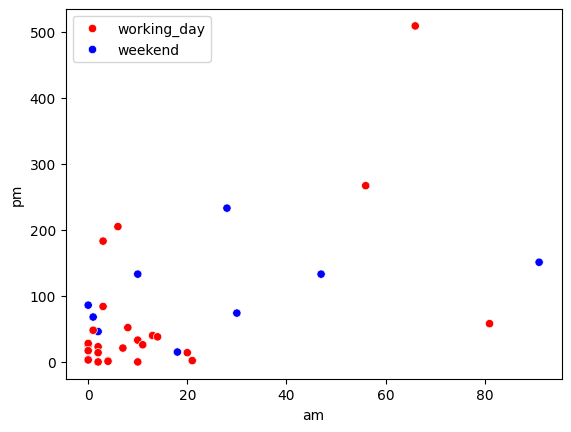

In [3]:
ax = sns.scatterplot(
    data=df, 
    x='am', 
    y='pm', 
    hue='target',
    palette={'working_day': 'red', 'weekend': 'blue'},
)
ax.legend(loc='upper left')

In [4]:
X = df[['am','pm']]
Y = df['target']

In [5]:
model = LogisticRegression(random_state=21,fit_intercept=False)
model.fit(X,Y)
model.coef_ #эквив coef_am * am + coef_pm * pm = 0 от _am; _pm

array([[-0.00038653,  0.00298066]])

In [6]:
#pm = (-am * x_1) / x_2
def func1_df(x1,x2,df):
    new_df = pd.DataFrame()
    new_df['am'] = df['am'] #т.к берем ось am
    new_df['pm'] = df['am'].apply(lambda x: (x * -x1) / x2)
    return new_df

x1 = model.coef_[0][0]
x2 = model.coef_[0][1]
new_df = func1_df(x1,x2,df)
new_df.head()

,am,pm
0,21,2.723245
1,1,0.129678
2,18,2.334210
3,2,0.259357
4,0,0.000000


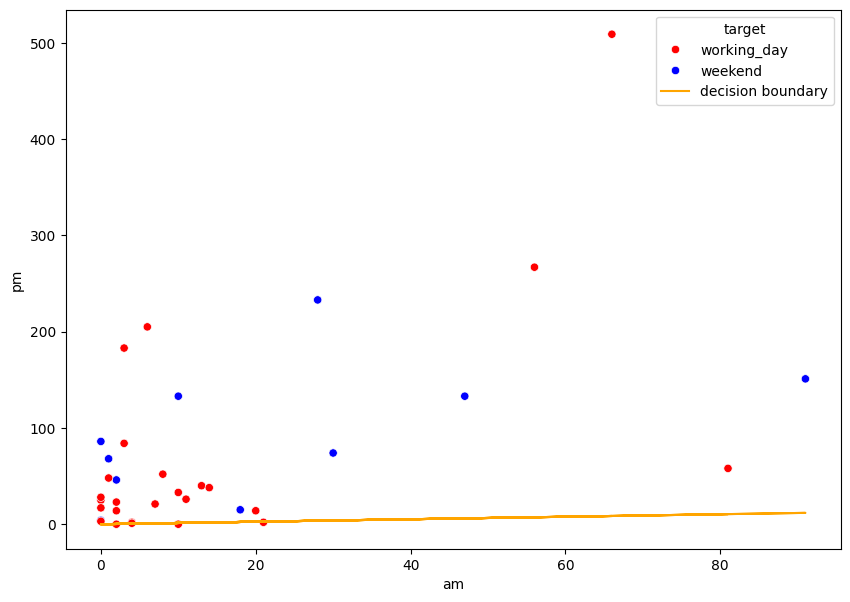

In [7]:
fig,ax = plt.subplots(figsize=(10,7))
sns.scatterplot(
    df,
    x=df['am'],
    y=df['pm'],
    hue='target',
    legend="full",
    palette={'working_day': 'red', 'weekend': 'blue'}
)
new_df.plot(
    x='am',
    y='pm',
    ax=ax, #рисовать по точкам
    c='orange',
    kind='line', #линия
    label='decision boundary' #добав к легенде
)
plt.show()

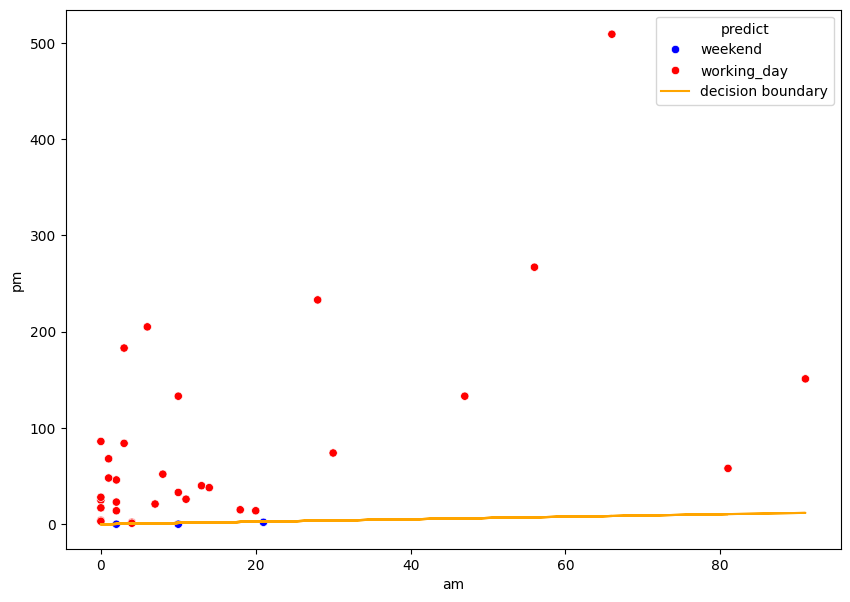

In [8]:
fig,ax = plt.subplots(figsize=(10,7))
sns.scatterplot(
    df,
    x=df['am'],
    y=df['pm'],
    hue='predict',
    legend="full",
    palette={'working_day': 'red', 'weekend': 'blue'}
)
new_df.plot(
    x='am',
    y='pm',
    ax=ax,
    c='orange',
    kind='line',
    label='decision boundary'
)
plt.show()

## 2. Standardizing and logreg

Linear models can be sensitive to the scale of your variables. You make it easier for them to find the optimal solution when you scale your features.

1. Apply `StandardScaler` to `X` and train logistic regression again with the same parameters.
2. Calculate `accuracy` for the new model. Did it get better than a naive classifier with the most popular class?
3. Draw the plots that were described above but for the new model.

In [9]:
scaler = StandardScaler() #Стандартное масштабирование
X_scaled = scaler.fit_transform(X) #x_scaled = (x - mean) / std | scaler.fit(X) + scaler.transform(X)
df[['am_sc','pm_sc']] = X_scaled
df


,date,am,pm,target,predict,am_sc,pm_sc
0,2020-04-17,21,2,working_day,weekend,0.200690,-0.719904
1,2020-04-18,1,68,weekend,working_day,-0.655914,-0.071822
2,2020-04-19,18,15,weekend,working_day,0.072199,-0.592251
3,2020-04-20,2,23,working_day,working_day,-0.613084,-0.513696
4,2020-04-21,0,25,working_day,working_day,-0.698744,-0.494057
5,2020-04-22,0,28,working_day,working_day,-0.698744,-0.464599
6,2020-04-23,10,33,working_day,working_day,-0.270442,-0.415502
7,2020-04-24,2,14,working_day,working_day,-0.613084,-0.602071
8,2020-04-25,30,74,weekend,working_day,0.586162,-0.012906
9,2020-04-26,28,233,weekend,working_day,0.500501,1.548382


In [10]:
model_scaled = LogisticRegression(random_state=21, fit_intercept=False)
model_scaled.fit(X_scaled, Y)
model_scaled.predict(X_scaled)

array(['working_day', 'working_day', 'working_day', 'working_day',
       'working_day', 'working_day', 'working_day', 'working_day',
       'weekend', 'weekend', 'working_day', 'working_day', 'working_day',
       'working_day', 'working_day', 'weekend', 'weekend', 'working_day',
       'weekend', 'working_day', 'working_day', 'working_day',
       'working_day', 'working_day', 'working_day', 'weekend',
       'working_day', 'weekend', 'working_day', 'working_day',
       'working_day', 'working_day', 'working_day', 'working_day',
       'working_day'], dtype=object)

In [11]:
df['predict_scaled'] = model_scaled.predict(X_scaled)
df.head() #исходные данные масштабирования

,date,am,pm,target,predict,am_sc,pm_sc,predict_scaled
0,2020-04-17,21,2,working_day,weekend,0.200690,-0.719904,working_day
1,2020-04-18,1,68,weekend,working_day,-0.655914,-0.071822,working_day
2,2020-04-19,18,15,weekend,working_day,0.072199,-0.592251,working_day
3,2020-04-20,2,23,working_day,working_day,-0.613084,-0.513696,working_day
4,2020-04-21,0,25,working_day,working_day,-0.698744,-0.494057,working_day


In [12]:
accuracy_score(df['target'], df['predict_scaled'])

0.7428571428571429

In [13]:
most_popular = df['target'].mode()[0]
print((df['target'] == most_popular).mean()) # => new_acc лучше наивной

0.7142857142857143


In [14]:
def func2_df(x1,x2,df):
    new_df = pd.DataFrame()
    new_df['am_sc'] = df['am_sc']
    new_df['pm_sc'] = df['am_sc'].apply(lambda x: (x * -x1) / x2)
    
    return new_df

x1 = model_scaled.coef_[0][0]
x2 = model_scaled.coef_[0][1]
new2_df = func2_df(x1,x2,df)
new2_df #ур-е прямой

,am_sc,pm_sc
0,0.200690,-0.690232
1,-0.655914,2.255880
2,0.072199,-0.248315
3,-0.613084,2.108574
4,-0.698744,2.403186
5,-0.698744,2.403186
6,-0.270442,0.930130
7,-0.613084,2.108574
8,0.586162,-2.015982
9,0.500501,-1.721371


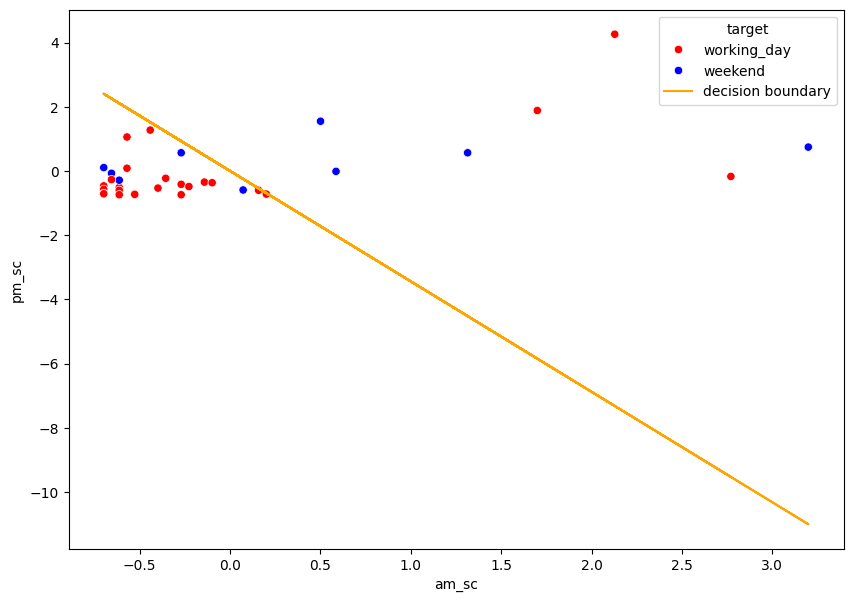

In [15]:
fig,ax = plt.subplots(figsize=(10,7))
sns.scatterplot(
    df,
    x=df['am_sc'],
    y=df['pm_sc'],
    hue='target',
    legend="full",
    palette={'working_day': 'red', 'weekend': 'blue'}
)
new2_df.plot(
    x='am_sc',
    y='pm_sc',
    ax=ax,
    c='orange',
    kind='line',
    label='decision boundary'
)
plt.show()

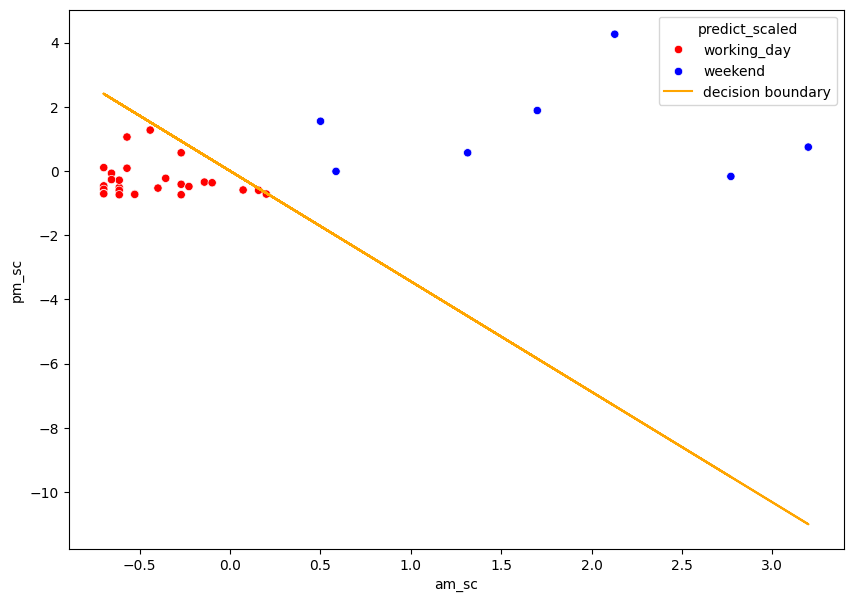

In [16]:
fig,ax = plt.subplots(figsize=(10,7))
sns.scatterplot(
    df,
    x=df['am_sc'],
    y=df['pm_sc'],
    hue='predict_scaled',
    legend="full",
    palette={'working_day': 'red', 'weekend': 'blue'}
)
new2_df.plot(
    x='am_sc',
    y='pm_sc',
    ax=ax,
    c='orange',
    kind='line',
    label='decision boundary'
)
plt.show()

## 3. SVM

1. Apply `SVC` model to the scaled dataframe using parameters `probability=True`, `random_state=21`.
2. Calculate `accuracy`.
3. Try different kernels, find the best in terms of accuracy.
4. Draw both plots again with the decisions boundary to see how this algorithm works.

rbf

In [17]:
model_svc = SVC(probability=True, random_state=21, kernel='rbf')
model_svc.fit(X_scaled, Y)

SVC(probability=True, random_state=21)

In [18]:
df_scaled = df.copy()
df_scaled['predict_svc'] = model_svc.predict(X_scaled)
df_scaled

,date,am,pm,target,predict,am_sc,pm_sc,predict_scaled,predict_svc
0,2020-04-17,21,2,working_day,weekend,0.200690,-0.719904,working_day,working_day
1,2020-04-18,1,68,weekend,working_day,-0.655914,-0.071822,working_day,working_day
2,2020-04-19,18,15,weekend,working_day,0.072199,-0.592251,working_day,working_day
3,2020-04-20,2,23,working_day,working_day,-0.613084,-0.513696,working_day,working_day
4,2020-04-21,0,25,working_day,working_day,-0.698744,-0.494057,working_day,working_day
5,2020-04-22,0,28,working_day,working_day,-0.698744,-0.464599,working_day,working_day
6,2020-04-23,10,33,working_day,working_day,-0.270442,-0.415502,working_day,working_day
7,2020-04-24,2,14,working_day,working_day,-0.613084,-0.602071,working_day,working_day
8,2020-04-25,30,74,weekend,working_day,0.586162,-0.012906,weekend,working_day
9,2020-04-26,28,233,weekend,working_day,0.500501,1.548382,weekend,working_day


In [19]:
accuracy_score(Y, model_svc.predict(X_scaled))

0.7428571428571429

linear

In [20]:
model_svc = SVC(probability=True, random_state=21, kernel='linear')
model_svc.fit(X_scaled, Y)
accuracy_score(Y, model_svc.predict(X_scaled))

0.7142857142857143

poly

In [21]:
model_svc = SVC(probability=True, random_state=21, kernel='poly')
model_svc.fit(X_scaled, Y)
accuracy_score(Y, model_svc.predict(X_scaled))

0.7428571428571429

sigmoid

In [22]:
model_svc = SVC(probability=True, random_state=21, kernel='sigmoid')
model_svc.fit(X_scaled, Y)
accuracy_score(Y, model_svc.predict(X_scaled))

0.6857142857142857

In [23]:
print(X_scaled)

[[ 0.20069005 -0.71990365]
 [-0.65591383 -0.07182203]
 [ 0.07219947 -0.59225121]
 [-0.61308363 -0.51369586]
 [-0.69874402 -0.49405703]
 [-0.69874402 -0.46459877]
 [-0.27044208 -0.41550168]
 [-0.61308363 -0.60207063]
 [ 0.5861618  -0.01290552]
 [ 0.50050141  1.54838202]
 [-0.52742324 -0.71990365]
 [-0.52742324 -0.72972307]
 [-0.69874402 -0.57261237]
 [-0.1419515  -0.34676575]
 [-0.35610247 -0.22893273]
 [ 3.19880362  0.7431897 ]
 [ 1.31427509  0.56644017]
 [-0.22761189 -0.48423761]
 [ 2.77050168 -0.17001622]
 [-0.61308363 -0.73954249]
 [-0.09912131 -0.36640459]
 [-0.57025344  0.08528866]
 [-0.69874402  0.1049275 ]
 [-0.27044208  0.56644017]
 [-0.57025344  1.05741109]
 [ 1.69974683  1.88224224]
 [-0.44176286  1.2734383 ]
 [ 2.12804877  4.25854152]
 [-0.27044208 -0.73954249]
 [-0.69874402 -0.70026481]
 [-0.61308363 -0.28784924]
 [-0.69874402 -0.71008423]
 [ 0.15785986 -0.60207063]
 [-0.39893266 -0.5333347 ]
 [-0.65591383 -0.2682104 ]]


precomputed невозможна, т.к нужна квадратная матрица на входе, а у нас 35 по X и всего 2 по Y

BEST: 0.7428571428571429

In [24]:
svc_rbf = SVC(
    kernel='rbf',
    probability=True,
    random_state=21
)
svc_rbf.fit(X_scaled, Y)


x_min, x_max = X_scaled[:, 0].min() - 0.5, X_scaled[:, 0].max() + 0.5 #все строки и столбец am_sc
y_min, y_max = X_scaled[:, 1].min() - 0.5, X_scaled[:, 1].max() + 0.5
xx, yy = np.meshgrid( #сетка из точек
    np.linspace(x_min, x_max, 200), #200 равномерных точек по х от 1 до 2 границ
    np.linspace(y_min, y_max, 200) #200 по y
# xx.shape = (200, 200); yy.shape = (200, 200) => 40000 точек в сетке
)
Z = svc_rbf.predict(np.c_[xx.ravel(), yy.ravel()]) #40000 строк, 2 по y
Z = (Z == 'working_day').astype(int).reshape(xx.shape) #из була в инт -> возвращает обратно в матрицу 200x200 для contour

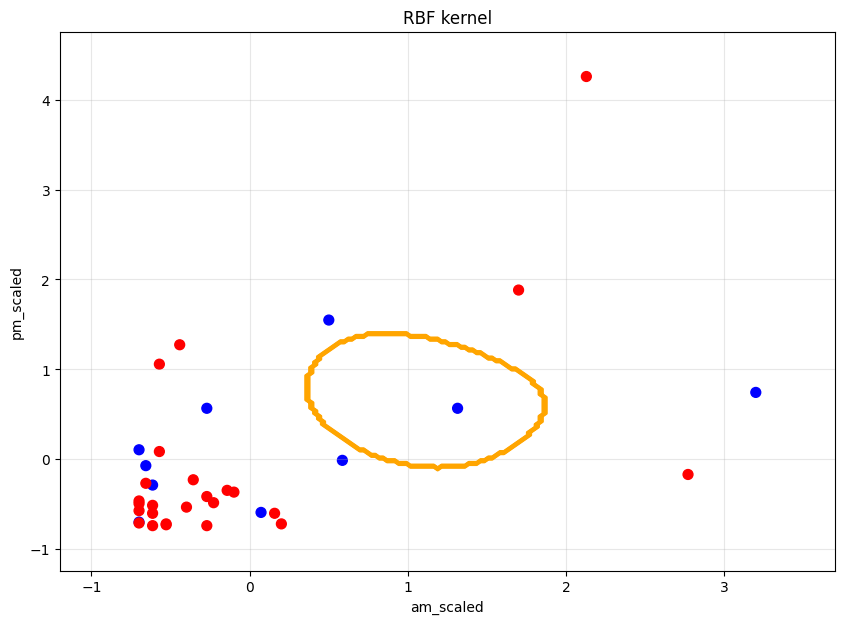

In [25]:
palette = {'working_day': 'red', 'weekend': 'blue'}
fig, ax = plt.subplots(figsize=(10, 7))
ax.contour( #граница кривой рисует границу между мереходом у матрицы Z 0 и 1
    xx,
    yy,
    Z,
    colors='orange',
    linewidths=2
)
ax.scatter( #точки
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=[palette[label] for label in Y],
    s=50,
)

ax.set_xlabel('am_scaled')
ax.set_ylabel('pm_scaled')
ax.set_title(f'RBF kernel')
ax.grid(True, alpha=0.3)
plt.show()

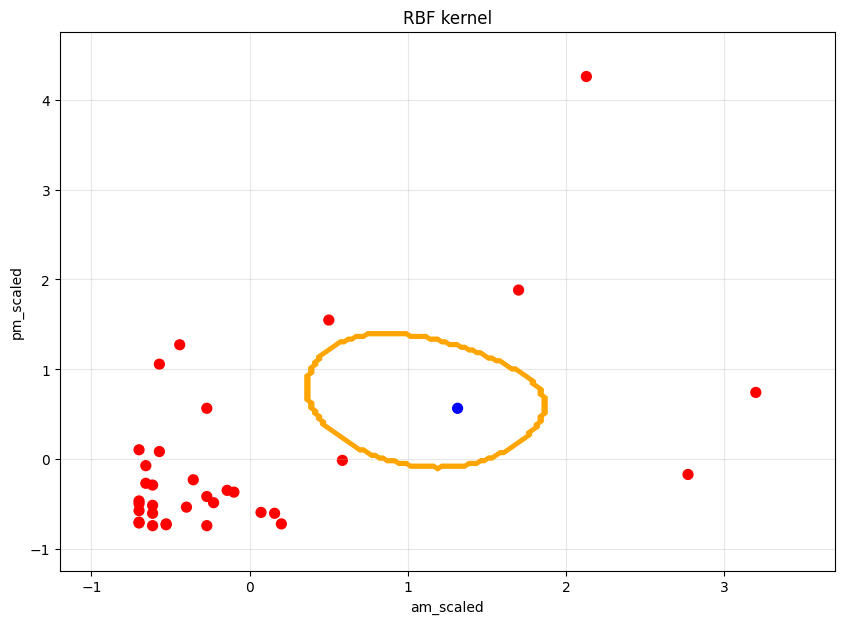

In [26]:
palette = {'working_day': 'red', 'weekend': 'blue'}
fig, ax = plt.subplots(figsize=(10, 7))
ax.contour( #граница кривой рисует границу между мереходом у матрицы Z 0 и 1
    xx,
    yy,
    Z,
    colors='orange',
    linewidths=2
)
ax.scatter( #точки
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=[palette[label] for label in df_scaled['predict_svc']],
    s=50,
)

ax.set_xlabel('am_scaled')
ax.set_ylabel('pm_scaled')
ax.set_title(f'RBF kernel')
ax.grid(True, alpha=0.3)
plt.show()

## 4. Decision tree

1. Apply `DecisionTreeClassifier` to the scaled dataframe using parameters `max_depth=4`, `random_state=42`.
2. Calculate accuracy.
3. Try different values of `max_depth`.
4. Draw both plots again with the decisions boundary to see how this algorithm works.
5. Using method `.plot_tree()` visualize the decision tree itself. It is another way of thinking about how the algorithm works.
6. How many leaves in the visualized tree label days as working days? Put your answer in the markdown cell in the end of the section.

In [27]:
model_tree = DecisionTreeClassifier(max_depth=4,random_state=42)
model_tree.fit(X_scaled, Y)

DecisionTreeClassifier(max_depth=4, random_state=42)

In [28]:
accuracy_score(Y, model_tree.predict(X_scaled))

0.9428571428571428

In [29]:
df['predict_tree'] = model_tree.predict(X_scaled)
df

,date,am,pm,target,predict,am_sc,pm_sc,predict_scaled,predict_tree
0,2020-04-17,21,2,working_day,weekend,0.200690,-0.719904,working_day,working_day
1,2020-04-18,1,68,weekend,working_day,-0.655914,-0.071822,working_day,weekend
2,2020-04-19,18,15,weekend,working_day,0.072199,-0.592251,working_day,working_day
3,2020-04-20,2,23,working_day,working_day,-0.613084,-0.513696,working_day,working_day
4,2020-04-21,0,25,working_day,working_day,-0.698744,-0.494057,working_day,working_day
5,2020-04-22,0,28,working_day,working_day,-0.698744,-0.464599,working_day,working_day
6,2020-04-23,10,33,working_day,working_day,-0.270442,-0.415502,working_day,working_day
7,2020-04-24,2,14,working_day,working_day,-0.613084,-0.602071,working_day,working_day
8,2020-04-25,30,74,weekend,working_day,0.586162,-0.012906,weekend,weekend
9,2020-04-26,28,233,weekend,working_day,0.500501,1.548382,weekend,weekend


In [30]:
for depth in [1, 2, 3, 4, 5, 6, 9, None]:
    tmp_model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    tmp_model.fit(X_scaled, Y)
    acc = accuracy_score(Y, tmp_model.predict(X_scaled))
    print(f'Max Depth - {depth} : {acc}')

Max Depth - 1 : 0.7714285714285715
Max Depth - 2 : 0.8571428571428571
Max Depth - 3 : 0.8857142857142857
Max Depth - 4 : 0.9428571428571428
Max Depth - 5 : 0.9714285714285714
Max Depth - 6 : 1.0
Max Depth - 9 : 1.0
Max Depth - None : 1.0


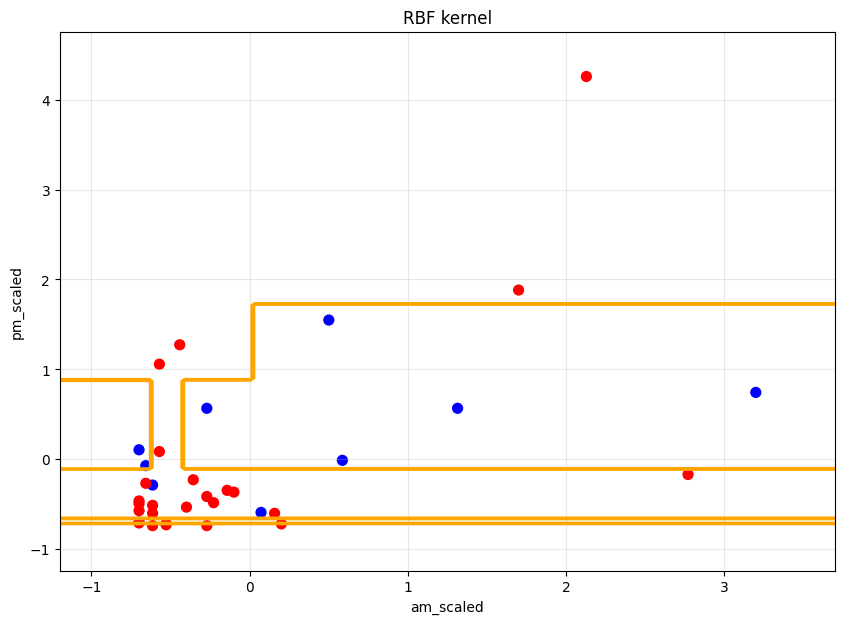

In [31]:
Z = model_tree.predict(np.c_[xx.ravel(), yy.ravel()])
Z = (Z == 'working_day').astype(int).reshape(xx.shape)
palette = {'working_day': 'red', 'weekend': 'blue'}
fig, ax = plt.subplots(figsize=(10, 7))
ax.contour( #граница кривой рисует границу между мереходом у матрицы Z 0 и 1
    xx,
    yy,
    Z,
    colors='orange',
    linewidths=1
)
ax.scatter( #точки
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=[palette[label] for label in Y],
    s=50,
)

ax.set_xlabel('am_scaled')
ax.set_ylabel('pm_scaled')
ax.set_title(f'RBF kernel')
ax.grid(True, alpha=0.3)
plt.show()

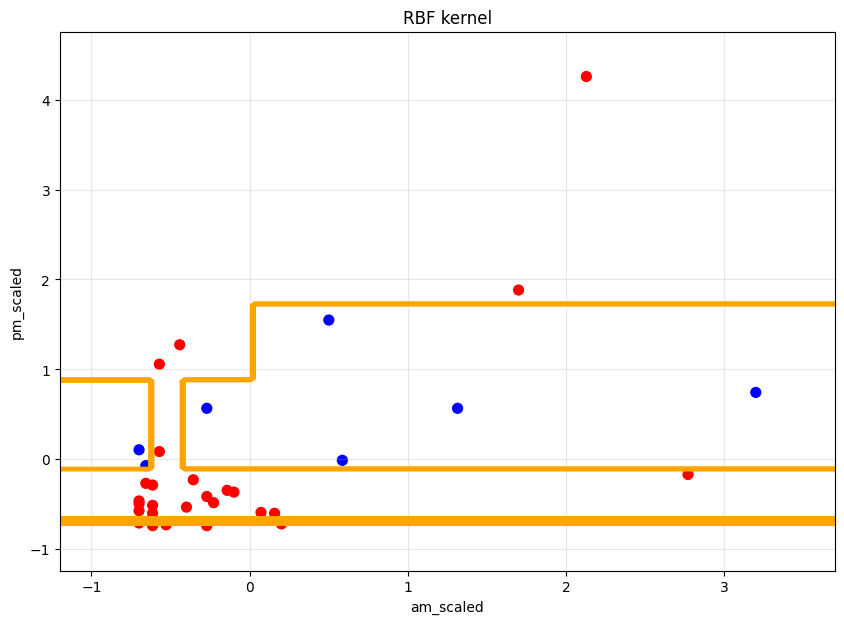

In [32]:
Z = model_tree.predict(np.c_[xx.ravel(), yy.ravel()])
Z = (Z == 'working_day').reshape(xx.shape).astype(int)
palette = {'working_day': 'red', 'weekend': 'blue'}
fig, ax = plt.subplots(figsize=(10, 7))
ax.contour( #граница кривой рисует границу между мереходом у матрицы Z 0 и 1
    xx,
    yy,
    Z,
    colors='orange',
    linewidths=2
)
ax.scatter( #точки
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=[palette[label] for label in df['predict_tree']],
    s=50,
)

ax.set_xlabel('am_scaled')
ax.set_ylabel('pm_scaled')
ax.set_title(f'RBF kernel')
ax.grid(True, alpha=0.3)
plt.show()

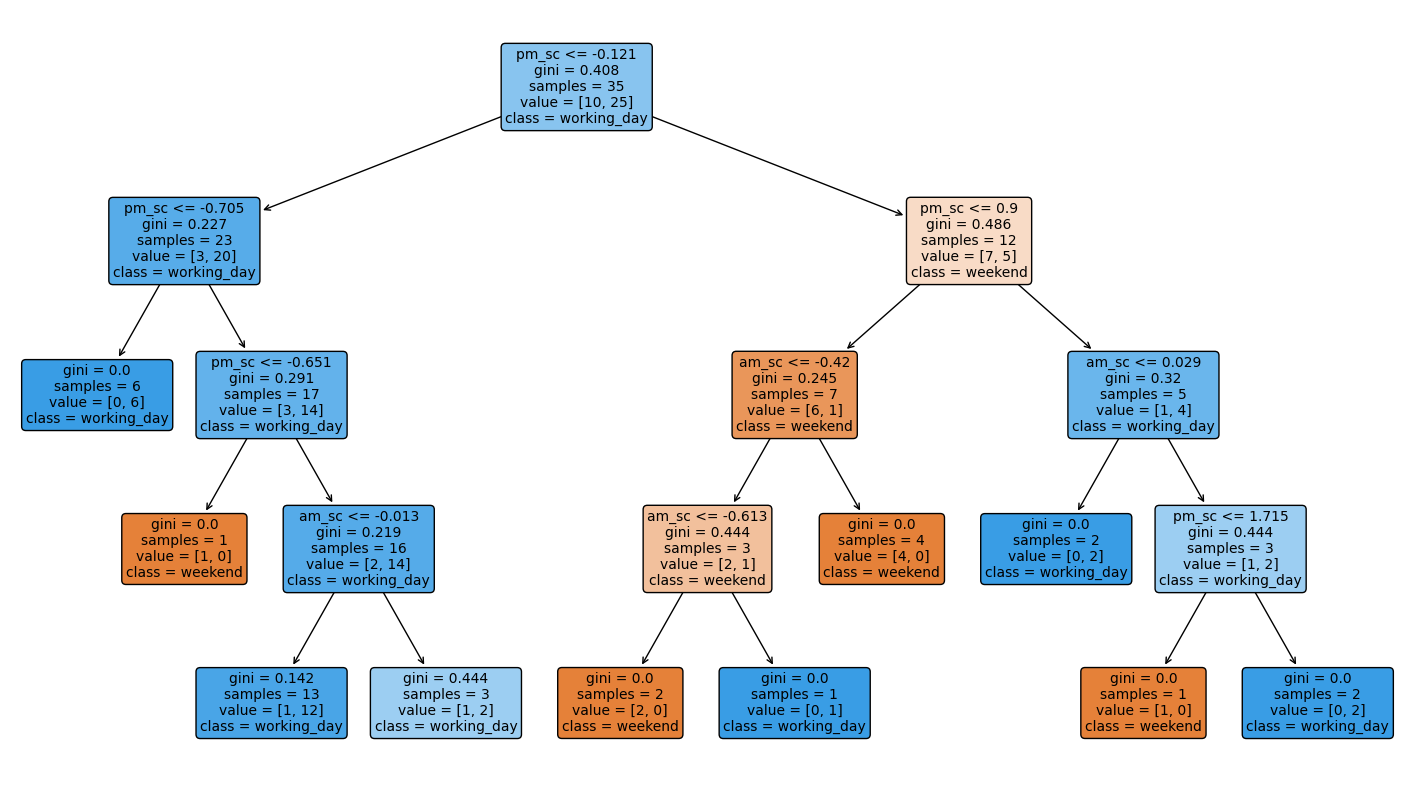

In [33]:
plt.figure(figsize=(18, 10))
tree.plot_tree(
    model_tree,
    feature_names=['am_sc', 'pm_sc'],
    class_names=['weekend', 'working_day'],    # порядок классов (как в Y.unique())
    filled=True, # закрасить узлы цветом
    rounded=True,
    fontsize=10
)
plt.show()

считаем те листы(working_day), явл. однородными: gini = 0 - точное определение:
1-q samples = 6; samples = 1; (samples = 2) * 2 =>
итог: 4 / опечатка, тогда будет 6 листов т.к листы - прям-ки у которые нет детей - продолжения